In [1]:
!pip install ucimlrepo joblib

# ===================================================
# PHASE 1: DATASET LOADING
# ===================================================

In [3]:
# =========================================================
# PHASE 1: DATASET LOADING (Fixed - direct download method)
# =========================================================

# ---- Import required libraries ----
import pandas as pd
import numpy as np
import requests
import zipfile
import io

# ---- Load the SMS Spam Collection dataset directly from UCI ----
def load_sms_dataset() -> pd.DataFrame:
    """
    Downloads the SMS Spam Collection dataset directly from the UCI
    static file server (bypasses ucimlrepo, which doesn't yet support
    this dataset's newer API format) and returns it as a DataFrame.

    Returns:
        pd.DataFrame: Raw SMS dataset with columns ['label', 'message']
    """
    url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

    # Download the zip file into memory
    response = requests.get(url)
    response.raise_for_status()  # raises an error if download failed

    # Open the zip in memory and extract the data file
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        with z.open("SMSSpamCollection") as f:
            df = pd.read_csv(f, sep="\t", header=None, names=["label", "message"])

    return df


# ---- Load the data ----
df = load_sms_dataset()

# ---- Display first five rows ----
print("First 5 rows of the dataset:")
print(df.head())

# ---- Dataset shape ----
print(f"\nDataset shape: {df.shape}")
print(f"Number of messages: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# ---- Dataset information (data types, non-null counts) ----
print("\nDataset info:")
df.info()

# ---- Dataset statistics ----
print("\nDataset statistics (categorical summary):")
print(df.describe())

First 5 rows of the dataset:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset shape: (5572, 2)
Number of messages: 5572
Number of columns: 2

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Dataset statistics (categorical summary):
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


# ===================================================
# PHASE 2: DATASET CLEANING
# ===================================================

In [4]:
# =========================================================
# PHASE 2: DATASET CLEANING
# =========================================================

# ---- Step 1: Missing value analysis ----
print("Missing values per column (before cleaning):")
print(df.isnull().sum())

# ---- Step 2: Duplicate check and removal ----
print(f"\nTotal rows before duplicate removal: {df.shape[0]}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Remove duplicates, keeping the first occurrence
df = df.drop_duplicates(keep="first").reset_index(drop=True)

print(f"Total rows after duplicate removal: {df.shape[0]}")

# ---- Step 3: Label encoding (spam=1, ham=0) ----
def encode_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encodes the 'label' column into a new numeric column 'label_num'.
    spam -> 1, ham -> 0

    Args:
        df (pd.DataFrame): DataFrame with a 'label' column containing 'spam'/'ham'

    Returns:
        pd.DataFrame: Same DataFrame with an added 'label_num' column
    """
    df["label_num"] = df["label"].map({"spam": 1, "ham": 0})
    return df

df = encode_labels(df)

# ---- Step 4: Before/after statistics ----
print("\nClass distribution after cleaning:")
print(df["label"].value_counts())

print("\nClass proportion after cleaning:")
print(df["label"].value_counts(normalize=True))

print("\nFirst 5 rows after cleaning and encoding:")
print(df.head())

print(f"\nFinal dataset shape: {df.shape}")

Missing values per column (before cleaning):
label      0
message    0
dtype: int64

Total rows before duplicate removal: 5572
Number of duplicate rows: 403
Total rows after duplicate removal: 5169

Class distribution after cleaning:
label
ham     4516
spam     653
Name: count, dtype: int64

Class proportion after cleaning:
label
ham     0.87367
spam    0.12633
Name: proportion, dtype: float64

First 5 rows after cleaning and encoding:
  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0

Final dataset shape: (5169, 3)


# ===================================================
# PHASE 3: EXPLORATORY DATA ANALYSIS
# ===================================================

Class counts:
label
ham     4516
spam     653
Name: count, dtype: int64


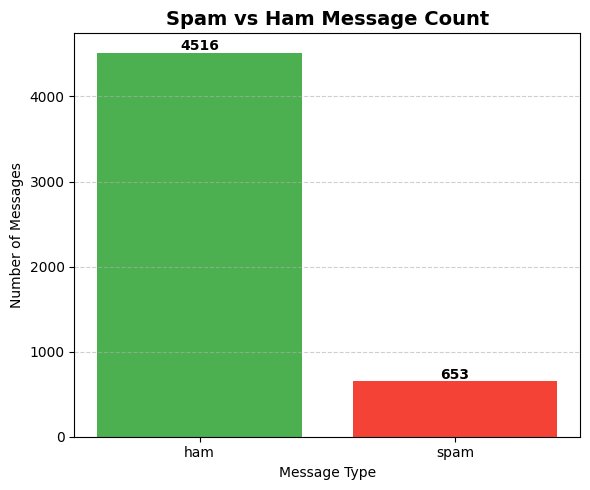

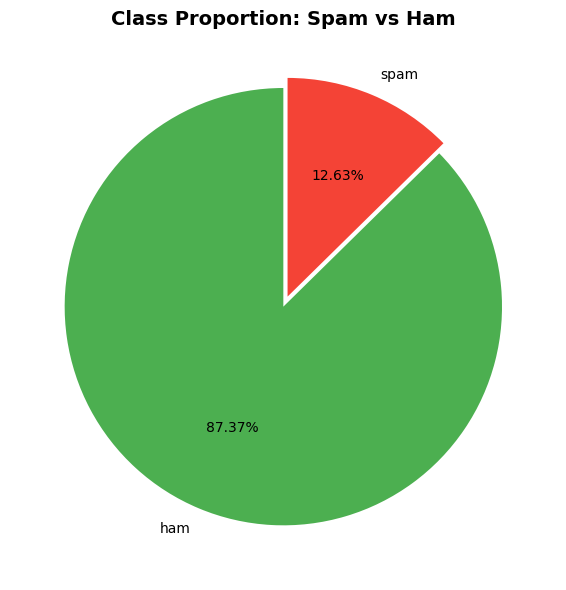


Message length statistics by class:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.905890  56.715046   2.0   34.0   53.0   91.0  910.0
spam    653.0  137.704441  29.821348  13.0  132.0  148.0  157.0  223.0


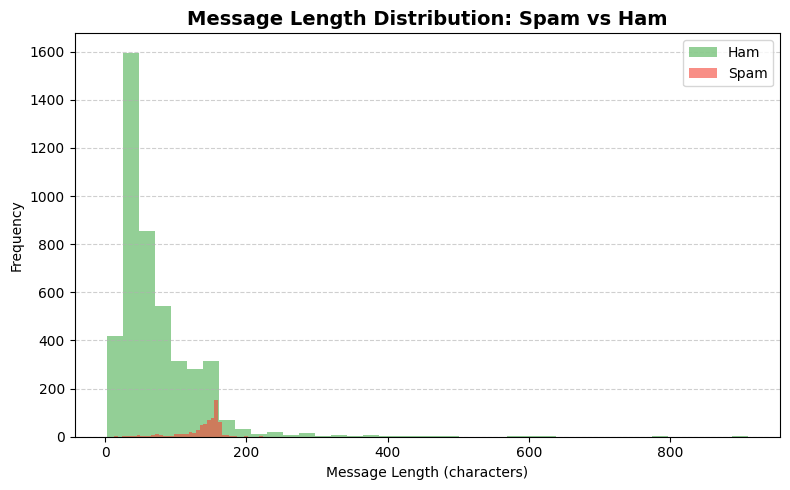

/tmp/ipykernel_7411/1186420840.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=["Ham", "Spam"], patch_artist=True)


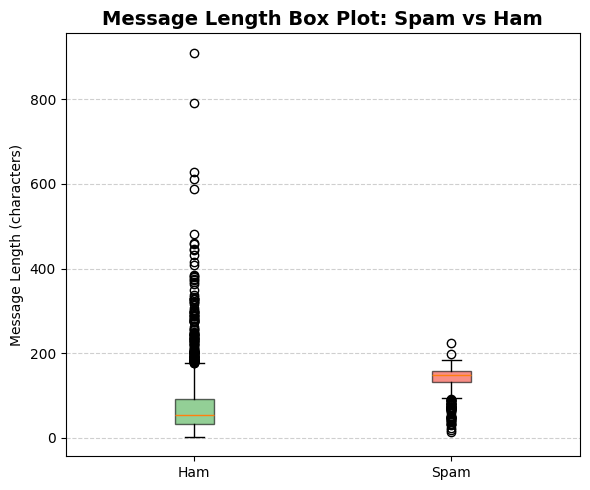


Top 15 words in SPAM messages:
  to: 599
  a: 335
  call: 309
  you: 268
  your: 242
  free: 195
  for: 185
  the: 183
  now: 164
  or: 157
  u: 147
  is: 144
  txt: 134
  on: 122
  from: 122

Top 15 words in HAM messages:
  i: 2793
  you: 1880
  to: 1481
  the: 1062
  a: 975
  u: 930
  and: 826
  in: 762
  me: 732
  my: 679
  it: 664
  is: 656
  that: 546
  for: 481
  s: 479


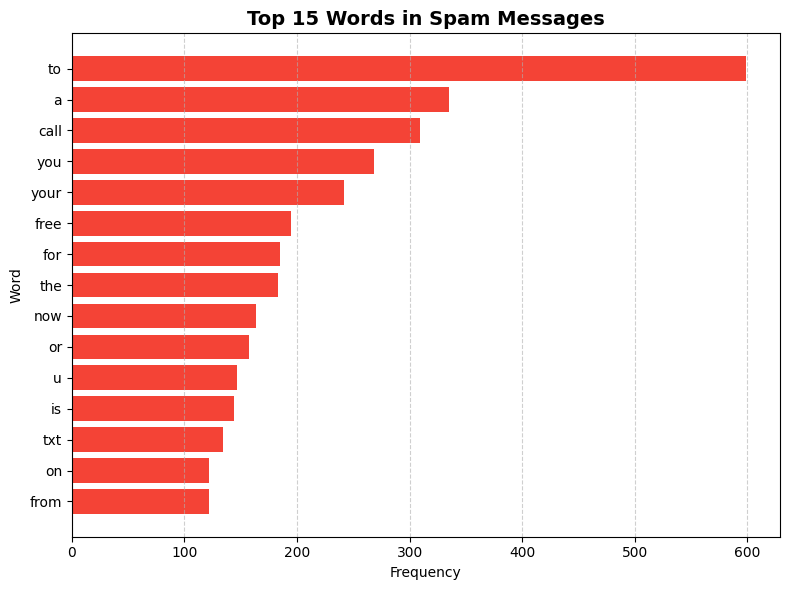

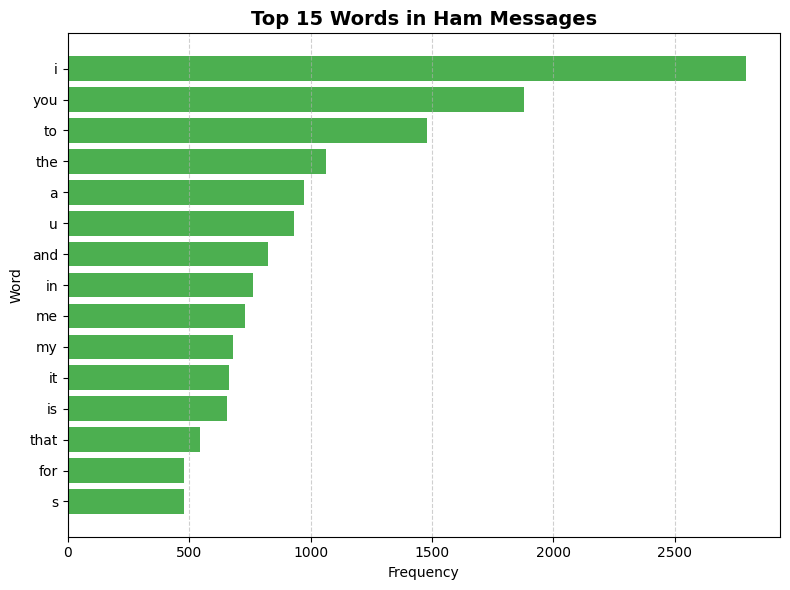

In [5]:
# =========================================================
# PHASE 3: EXPLORATORY DATA ANALYSIS
# =========================================================
import matplotlib.pyplot as plt

# ---- Step 1: Class distribution counts ----
class_counts = df["label"].value_counts()
print("Class counts:")
print(class_counts)

# ---- Step 2: Bar chart - Spam vs Ham count ----
def plot_class_bar_chart(counts: pd.Series) -> None:
    """
    Plots a bar chart showing the count of spam vs ham messages.

    Args:
        counts (pd.Series): value_counts() output of the 'label' column
    """
    plt.figure(figsize=(6, 5))
    bars = plt.bar(counts.index, counts.values, color=["#4CAF50", "#F44336"])

    plt.title("Spam vs Ham Message Count", fontsize=14, fontweight="bold")
    plt.xlabel("Message Type")
    plt.ylabel("Number of Messages")
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 30,
                  str(height), ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_class_bar_chart(class_counts)

# ---- Step 3: Pie chart - class proportion ----
def plot_class_pie_chart(counts: pd.Series) -> None:
    """
    Plots a pie chart showing the proportion of spam vs ham messages.

    Args:
        counts (pd.Series): value_counts() output of the 'label' column
    """
    plt.figure(figsize=(6, 6))
    plt.pie(counts.values, labels=counts.index, autopct="%1.2f%%",
            colors=["#4CAF50", "#F44336"], startangle=90,
            explode=(0, 0.05))  # slightly pull out the spam slice

    plt.title("Class Proportion: Spam vs Ham", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_class_pie_chart(class_counts)

# ---- Step 4: Message length column ----
df["message_length"] = df["message"].apply(len)

print("\nMessage length statistics by class:")
print(df.groupby("label")["message_length"].describe())

# ---- Step 5: Message length histogram ----
def plot_length_histogram(df: pd.DataFrame) -> None:
    """
    Plots overlapping histograms of message length, split by class.

    Args:
        df (pd.DataFrame): DataFrame containing 'message_length' and 'label'
    """
    plt.figure(figsize=(8, 5))
    plt.hist(df[df["label"] == "ham"]["message_length"], bins=40,
              alpha=0.6, label="Ham", color="#4CAF50")
    plt.hist(df[df["label"] == "spam"]["message_length"], bins=40,
              alpha=0.6, label="Spam", color="#F44336")

    plt.title("Message Length Distribution: Spam vs Ham", fontsize=14, fontweight="bold")
    plt.xlabel("Message Length (characters)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_length_histogram(df)

# ---- Step 6: Box plot of message length by class ----
def plot_length_boxplot(df: pd.DataFrame) -> None:
    """
    Plots a box plot comparing message length distributions for spam vs ham.

    Args:
        df (pd.DataFrame): DataFrame containing 'message_length' and 'label'
    """
    plt.figure(figsize=(6, 5))
    data_to_plot = [df[df["label"] == "ham"]["message_length"],
                     df[df["label"] == "spam"]["message_length"]]

    box = plt.boxplot(data_to_plot, labels=["Ham", "Spam"], patch_artist=True)
    colors = ["#4CAF50", "#F44336"]
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    plt.title("Message Length Box Plot: Spam vs Ham", fontsize=14, fontweight="bold")
    plt.ylabel("Message Length (characters)")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_length_boxplot(df)

# ---- Step 7: Word frequency analysis ----
import re
from collections import Counter

def get_word_frequency(messages: pd.Series, top_n: int = 15) -> list:
    """
    Extracts the most common words from a series of messages.

    Args:
        messages (pd.Series): Series of raw text messages
        top_n (int): Number of top words to return

    Returns:
        list: List of (word, count) tuples
    """
    all_words = []
    for msg in messages:
        words = re.findall(r"\b[a-z]+\b", msg.lower())  # extract lowercase words only
        all_words.extend(words)
    return Counter(all_words).most_common(top_n)

spam_word_freq = get_word_frequency(df[df["label"] == "spam"]["message"])
ham_word_freq = get_word_frequency(df[df["label"] == "ham"]["message"])

print("\nTop 15 words in SPAM messages:")
for word, count in spam_word_freq:
    print(f"  {word}: {count}")

print("\nTop 15 words in HAM messages:")
for word, count in ham_word_freq:
    print(f"  {word}: {count}")

# ---- Step 8: Bar chart for spam word frequency ----
def plot_word_frequency(word_freq: list, title: str, color: str) -> None:
    """
    Plots a horizontal bar chart of top word frequencies.

    Args:
        word_freq (list): List of (word, count) tuples
        title (str): Chart title
        color (str): Bar color
    """
    words, counts = zip(*word_freq)
    plt.figure(figsize=(8, 6))
    plt.barh(words, counts, color=color)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.gca().invert_yaxis()  # highest frequency on top
    plt.tight_layout()
    plt.show()

plot_word_frequency(spam_word_freq, "Top 15 Words in Spam Messages", "#F44336")
plot_word_frequency(ham_word_freq, "Top 15 Words in Ham Messages", "#4CAF50")

# ===================================================
# PHASE 4: PROBABILITY ANALYSIS
# ===================================================

In [6]:
# =========================================================
# PHASE 4: PROBABILITY ANALYSIS
# =========================================================

# ---- Step 1: Prior probabilities ----
total_messages = len(df)
total_spam = (df["label"] == "spam").sum()
total_ham = (df["label"] == "ham").sum()

P_spam = total_spam / total_messages
P_ham = total_ham / total_messages

print("=== PRIOR PROBABILITIES ===")
print(f"P(Spam) = {total_spam} / {total_messages} = {P_spam:.4f}")
print(f"P(Ham)  = {total_ham} / {total_messages} = {P_ham:.4f}")
print(f"Check: P(Spam) + P(Ham) = {P_spam + P_ham:.4f}  (should be 1.0)")


# ---- Step 2: Conditional probability - direct (empirical) method ----
def direct_conditional_probability(df: pd.DataFrame, word: str) -> dict:
    """
    Calculates P(Spam | word) directly using frequency counts:
    (messages with word AND spam) / (messages with word)

    Args:
        df (pd.DataFrame): Cleaned dataset with 'label' and 'message' columns
        word (str): The word to search for (case-insensitive, whole word match)

    Returns:
        dict: Contains counts and the calculated P(Spam | word)
    """
    # Build a boolean mask: does the message contain this word (whole word, case-insensitive)?
    pattern = r"\b" + re.escape(word) + r"\b"
    contains_word = df["message"].str.contains(pattern, case=False, regex=True)

    total_with_word = contains_word.sum()
    spam_with_word = (contains_word & (df["label"] == "spam")).sum()

    p_spam_given_word = spam_with_word / total_with_word if total_with_word > 0 else 0.0

    return {
        "word": word,
        "total_with_word": total_with_word,
        "spam_with_word": spam_with_word,
        "P_spam_given_word_direct": p_spam_given_word
    }


# ---- Step 3: Conditional probability - Bayes' Theorem method ----
def bayes_conditional_probability(df: pd.DataFrame, word: str, P_spam: float, P_ham: float) -> dict:
    """
    Calculates P(Spam | word) using Bayes' Theorem:
    P(Spam|Word) = [P(Word|Spam) * P(Spam)] / P(Word)

    Args:
        df (pd.DataFrame): Cleaned dataset
        word (str): The word to search for
        P_spam (float): Prior probability of spam
        P_ham (float): Prior probability of ham

    Returns:
        dict: Contains intermediate probabilities and the final P(Spam | word)
    """
    pattern = r"\b" + re.escape(word) + r"\b"
    contains_word = df["message"].str.contains(pattern, case=False, regex=True)

    spam_msgs = df[df["label"] == "spam"]
    ham_msgs = df[df["label"] == "ham"]

    # P(Word | Spam): fraction of spam messages containing the word
    word_in_spam = contains_word[df["label"] == "spam"].sum()
    P_word_given_spam = word_in_spam / len(spam_msgs)

    # P(Word | Ham): fraction of ham messages containing the word
    word_in_ham = contains_word[df["label"] == "ham"].sum()
    P_word_given_ham = word_in_ham / len(ham_msgs)

    # P(Word): law of total probability
    P_word = (P_word_given_spam * P_spam) + (P_word_given_ham * P_ham)

    # Bayes' Theorem
    P_spam_given_word = (P_word_given_spam * P_spam) / P_word if P_word > 0 else 0.0

    return {
        "word": word,
        "P_word_given_spam": P_word_given_spam,
        "P_word_given_ham": P_word_given_ham,
        "P_word": P_word,
        "P_spam_given_word_bayes": P_spam_given_word
    }


# ---- Step 4: Run analysis for all five suspicious words ----
suspicious_words = ["free", "prize", "win", "urgent", "offer"]

print("\n\n=== CONDITIONAL PROBABILITY ANALYSIS (5 words) ===\n")

results = []
for word in suspicious_words:
    direct = direct_conditional_probability(df, word)
    bayes = bayes_conditional_probability(df, word, P_spam, P_ham)

    print(f"--- Word: '{word}' ---")
    print(f"  Messages containing '{word}': {direct['total_with_word']}")
    print(f"  Of which spam: {direct['spam_with_word']}")
    print(f"  Direct  P(Spam | '{word}') = {direct['P_spam_given_word_direct']:.4f}")
    print(f"  Bayes'  P('{word}' | Spam) = {bayes['P_word_given_spam']:.4f}")
    print(f"  Bayes'  P('{word}' | Ham)  = {bayes['P_word_given_ham']:.4f}")
    print(f"  Bayes'  P('{word}')        = {bayes['P_word']:.4f}")
    print(f"  Bayes'  P(Spam | '{word}') = {bayes['P_spam_given_word_bayes']:.4f}")

    match = abs(direct['P_spam_given_word_direct'] - bayes['P_spam_given_word_bayes']) < 1e-9
    print(f"  ✓ Direct and Bayes' results match: {match}\n")

    results.append({
        "word": word,
        "direct": direct['P_spam_given_word_direct'],
        "bayes": bayes['P_spam_given_word_bayes']
    })

# ---- Step 5: Summary table ----
summary_df = pd.DataFrame(results)
summary_df.columns = ["Word", "P(Spam|Word) - Direct", "P(Spam|Word) - Bayes"]
print("=== SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

=== PRIOR PROBABILITIES ===
P(Spam) = 653 / 5169 = 0.1263
P(Ham)  = 4516 / 5169 = 0.8737
Check: P(Spam) + P(Ham) = 1.0000  (should be 1.0)


=== CONDITIONAL PROBABILITY ANALYSIS (5 words) ===

--- Word: 'free' ---
  Messages containing 'free': 203
  Of which spam: 148
  Direct  P(Spam | 'free') = 0.7291
  Bayes'  P('free' | Spam) = 0.2266
  Bayes'  P('free' | Ham)  = 0.0122
  Bayes'  P('free')        = 0.0393
  Bayes'  P(Spam | 'free') = 0.7291
  ✓ Direct and Bayes' results match: True

--- Word: 'prize' ---
  Messages containing 'prize': 73
  Of which spam: 73
  Direct  P(Spam | 'prize') = 1.0000
  Bayes'  P('prize' | Spam) = 0.1118
  Bayes'  P('prize' | Ham)  = 0.0000
  Bayes'  P('prize')        = 0.0141
  Bayes'  P(Spam | 'prize') = 1.0000
  ✓ Direct and Bayes' results match: True

--- Word: 'win' ---
  Messages containing 'win': 55
  Of which spam: 49
  Direct  P(Spam | 'win') = 0.8909
  Bayes'  P('win' | Spam) = 0.0750
  Bayes'  P('win' | Ham)  = 0.0013
  Bayes'  P('win')        =

# ===================================================
# PHASE 5: RANDOM VARIABLE ANALYSIS
# ===================================================

In [7]:
# =========================================================
# PHASE 5: RANDOM VARIABLE ANALYSIS
# =========================================================

# ---- Step 1: Define the Bernoulli random variable ----
# Y = 1 if Spam, Y = 0 if Ham
# This is already represented by our 'label_num' column from Phase 2
Y = df["label_num"]

print("=== BERNOULLI RANDOM VARIABLE: Y ===")
print("Y = 1 -> Spam, Y = 0 -> Ham")
print(f"\nFirst 10 values of Y:\n{Y.head(10).values}")
print(f"\nTotal observations: {len(Y)}")

# ---- Step 2: Calculate p = P(Spam) ----
p = Y.mean()  # mean of a 0/1 column = proportion of 1s = P(Spam)
print(f"\np = P(Spam) = {p:.4f}")

# ---- Step 3: Expectation E(Y) ----
def calculate_expectation(Y: pd.Series) -> float:
    """
    Calculates the expectation E(Y) of a Bernoulli random variable.
    For Bernoulli, E(Y) = p = mean of Y.

    Args:
        Y (pd.Series): Series of 0/1 values

    Returns:
        float: E(Y)
    """
    return Y.mean()

E_Y = calculate_expectation(Y)
print(f"\n=== EXPECTATION ===")
print(f"E(Y) = mean(Y) = {E_Y:.4f}")
print(f"Compare to P(Spam) from Phase 4: {P_spam:.4f}")
print(f"Match: {np.isclose(E_Y, P_spam)}")

# ---- Step 4: Variance Var(Y) ----
def calculate_variance(p: float) -> float:
    """
    Calculates the theoretical variance of a Bernoulli random variable.
    Var(Y) = p * (1 - p)

    Args:
        p (float): Probability of success (spam)

    Returns:
        float: Var(Y)
    """
    return p * (1 - p)

Var_Y_formula = calculate_variance(p)
Var_Y_pandas = Y.var(ddof=0)  # population variance, for direct comparison to the formula

print(f"\n=== VARIANCE ===")
print(f"Var(Y) using formula p(1-p) = {p:.4f} * {1-p:.4f} = {Var_Y_formula:.4f}")
print(f"Var(Y) using pandas .var()  = {Var_Y_pandas:.4f}")
print(f"Match: {np.isclose(Var_Y_formula, Var_Y_pandas)}")

# ---- Step 5: Standard deviation (bonus - useful for interpretation) ----
Std_Y = np.sqrt(Var_Y_formula)
print(f"\nStandard Deviation SD(Y) = sqrt(Var(Y)) = {Std_Y:.4f}")

# ---- Step 6: Interpretation summary ----
print("\n=== INTERPRETATION ===")
print(f"E(Y) = {E_Y:.4f} -> On average, about {E_Y*100:.1f}% of messages are spam.")
print(f"Var(Y) = {Var_Y_formula:.4f} -> Relatively low variance, since p is far from 0.5,")
print(f"          meaning the outcome (spam/ham) is fairly predictable in aggregate")
print(f"          (most messages are ham).")

=== BERNOULLI RANDOM VARIABLE: Y ===
Y = 1 -> Spam, Y = 0 -> Ham

First 10 values of Y:
[0 0 1 0 0 1 0 0 1 1]

Total observations: 5169

p = P(Spam) = 0.1263

=== EXPECTATION ===
E(Y) = mean(Y) = 0.1263
Compare to P(Spam) from Phase 4: 0.1263
Match: True

=== VARIANCE ===
Var(Y) using formula p(1-p) = 0.1263 * 0.8737 = 0.1104
Var(Y) using pandas .var()  = 0.1104
Match: True

Standard Deviation SD(Y) = sqrt(Var(Y)) = 0.3322

=== INTERPRETATION ===
E(Y) = 0.1263 -> On average, about 12.6% of messages are spam.
Var(Y) = 0.1104 -> Relatively low variance, since p is far from 0.5,
          meaning the outcome (spam/ham) is fairly predictable in aggregate
          (most messages are ham).


# ===================================================
# PHASE 6: FEATURE ENGINEERING
# ===================================================

In [8]:
# =========================================================
# PHASE 6: FEATURE ENGINEERING
# =========================================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# ---- Step 1: Define features (X) and target (y) ----
X = df["message"]        # raw text messages
y = df["label_num"]      # 0 = ham, 1 = spam

# ---- Step 2: Train-test split with stratified sampling ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 80% train, 20% test
    random_state=42,      # for reproducibility
    stratify=y            # preserves the spam/ham ratio in both sets
)

print("=== TRAIN-TEST SPLIT ===")
print(f"Training set size: {len(X_train)} messages")
print(f"Testing set size:  {len(X_test)} messages")

print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))

print(f"\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))

# ---- Step 3: Apply CountVectorizer ----
def build_vectorizer_and_transform(X_train: pd.Series, X_test: pd.Series):
    """
    Fits a CountVectorizer on training text and transforms both
    training and test sets into numeric sparse matrices.

    Args:
        X_train (pd.Series): Raw training messages
        X_test (pd.Series): Raw test messages

    Returns:
        tuple: (vectorizer, X_train_vec, X_test_vec)
    """
    vectorizer = CountVectorizer()

    # Fit ONLY on training data, then transform training data
    X_train_vec = vectorizer.fit_transform(X_train)

    # Transform test data using the SAME fitted vocabulary (no re-fitting!)
    X_test_vec = vectorizer.transform(X_test)

    return vectorizer, X_train_vec, X_test_vec

vectorizer, X_train_vec, X_test_vec = build_vectorizer_and_transform(X_train, X_test)

# ---- Step 4: Inspect vocabulary and matrix dimensions ----
vocab_size = len(vectorizer.vocabulary_)
print(f"\n=== VECTORIZATION RESULTS ===")
print(f"Vocabulary size: {vocab_size} unique words")

print(f"\nSparse matrix dimensions:")
print(f"  X_train_vec shape: {X_train_vec.shape}  (messages x vocabulary)")
print(f"  X_test_vec shape:  {X_test_vec.shape}")

# ---- Step 5: Sparsity check ----
non_zero = X_train_vec.nnz
total_cells = X_train_vec.shape[0] * X_train_vec.shape[1]
sparsity = 1 - (non_zero / total_cells)
print(f"\nMatrix sparsity: {sparsity:.4%} of cells are zero")
print(f"(This is expected -- each message only uses a tiny fraction of the full vocabulary)")

# ---- Step 6: Show top features (first 20 vocabulary words alphabetically) ----
feature_names = vectorizer.get_feature_names_out()
print(f"\nFirst 20 features in vocabulary (alphabetical):")
print(feature_names[:20])

# ---- Step 7: Most frequent words overall (by total count across training set) ----
word_counts = np.asarray(X_train_vec.sum(axis=0)).flatten()
top_indices = word_counts.argsort()[-15:][::-1]
print(f"\nTop 15 most frequent words in training vocabulary:")
for idx in top_indices:
    print(f"  {feature_names[idx]}: {word_counts[idx]}")

=== TRAIN-TEST SPLIT ===
Training set size: 4135 messages
Testing set size:  1034 messages

Training set class distribution:
label_num
0    0.873761
1    0.126239
Name: proportion, dtype: float64

Testing set class distribution:
label_num
0    0.873308
1    0.126692
Name: proportion, dtype: float64

=== VECTORIZATION RESULTS ===
Vocabulary size: 7680 unique words

Sparse matrix dimensions:
  X_train_vec shape: (4135, 7680)  (messages x vocabulary)
  X_test_vec shape:  (1034, 7680)

Matrix sparsity: 99.8276% of cells are zero
(This is expected -- each message only uses a tiny fraction of the full vocabulary)

First 20 features in vocabulary (alphabetical):
['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02' '0207' '02072069400' '03' '04' '0430'
 '05' '050703' '0578' '06' '07']

Top 15 most frequent words in training vocabulary:
  you: 1723
  to: 1650
  the: 1029
  and: 773
  in: 665
  is: 651
  me: 607
  it: 575
  my: 563
  for: 553
  your: 4

# ======================================================
# PHASE 7: MACHINE LEARNING MODEL - MULTINOMIAL NAIVE BAYES
# ======================================================

In [9]:
# =========================================================
# PHASE 7: MACHINE LEARNING MODEL - MULTINOMIAL NAIVE BAYES
# =========================================================
from sklearn.naive_bayes import MultinomialNB

# ---- Step 1: Initialize the model ----
# alpha=1.0 applies Laplace smoothing (default, prevents zero-probability issue)
model = MultinomialNB(alpha=1.0)

# ---- Step 2: Train the model ----
def train_naive_bayes(model: MultinomialNB, X_train_vec, y_train: pd.Series) -> MultinomialNB:
    """
    Trains a Multinomial Naive Bayes model on vectorized training data.

    Args:
        model (MultinomialNB): An initialized (untrained) MultinomialNB instance
        X_train_vec: Sparse matrix of training features (from CountVectorizer)
        y_train (pd.Series): Training labels (0=ham, 1=spam)

    Returns:
        MultinomialNB: The trained model
    """
    model.fit(X_train_vec, y_train)
    return model

model = train_naive_bayes(model, X_train_vec, y_train)

print("=== MODEL TRAINING COMPLETE ===")
print(f"Model type: {type(model).__name__}")
print(f"Smoothing parameter (alpha): {model.alpha}")
print(f"Classes learned: {model.classes_}  (0=Ham, 1=Spam)")

# ---- Step 3: Inspect learned class log-priors ----
# These correspond to log(P(Ham)) and log(P(Spam)) learned from training data
class_priors = np.exp(model.class_log_prior_)
print(f"\nLearned class priors (should closely match our Phase 4/5 P(Spam), P(Ham)):")
for cls, prior in zip(model.classes_, class_priors):
    label = "Ham" if cls == 0 else "Spam"
    print(f"  P({label}) learned by model = {prior:.4f}")

# ---- Step 4: Quick sanity check - training accuracy ----
train_accuracy = model.score(X_train_vec, y_train)
print(f"\nTraining set accuracy: {train_accuracy:.4f}")
print("(Note: this is NOT our real evaluation -- just a sanity check that training worked.")
print(" True evaluation happens in Phase 8, on the unseen test set.)")

# ---- Step 5: Demonstrate Laplace smoothing effect on an example word ----
# Pick a word from our suspicious list to show smoothed probability estimates
example_word = "free"
if example_word in vectorizer.vocabulary_:
    word_idx = vectorizer.vocabulary_[example_word]
    # feature_log_prob_ gives log P(word | class) after smoothing
    log_prob_ham = model.feature_log_prob_[0][word_idx]
    log_prob_spam = model.feature_log_prob_[1][word_idx]
    print(f"\n=== Laplace-Smoothed Probabilities for '{example_word}' ===")
    print(f"  P('{example_word}' | Ham)  = {np.exp(log_prob_ham):.5f}")
    print(f"  P('{example_word}' | Spam) = {np.exp(log_prob_spam):.5f}")
    print(f"  (Compare to our manual Phase 4 calculation: P(free|Spam)=0.2266, P(free|Ham)=0.0122)")
    print(f"  Small differences are expected -- smoothing adjusts slightly, and Phase 4 used whole-word")
    print(f"  regex matching on raw text, while CountVectorizer tokenizes differently.)")

=== MODEL TRAINING COMPLETE ===
Model type: MultinomialNB
Smoothing parameter (alpha): 1.0
Classes learned: [0 1]  (0=Ham, 1=Spam)

Learned class priors (should closely match our Phase 4/5 P(Spam), P(Ham)):
  P(Ham) learned by model = 0.8738
  P(Spam) learned by model = 0.1262

Training set accuracy: 0.9927
(Note: this is NOT our real evaluation -- just a sanity check that training worked.
 True evaluation happens in Phase 8, on the unseen test set.)

=== Laplace-Smoothed Probabilities for 'free' ===
  P('free' | Ham)  = 0.00077
  P('free' | Spam) = 0.00781
  (Compare to our manual Phase 4 calculation: P(free|Spam)=0.2266, P(free|Ham)=0.0122)
  Small differences are expected -- smoothing adjusts slightly, and Phase 4 used whole-word
  regex matching on raw text, while CountVectorizer tokenizes differently.)


# ======================================================
# PHASE 8: MODEL EVALUATION
# ======================================================

=== EVALUATION METRICS (on unseen TEST set) ===
Accuracy:  0.9816
Precision: 0.9590
Recall:    0.8931
F1-Score:  0.9249

=== CONFUSION MATRIX ===
[[898   5]
 [ 14 117]]

True Negatives (Ham correctly identified):  898
False Positives (Ham wrongly flagged Spam): 5  <- worse error type
False Negatives (Spam that slipped through): 14
True Positives (Spam correctly identified): 117

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.96      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



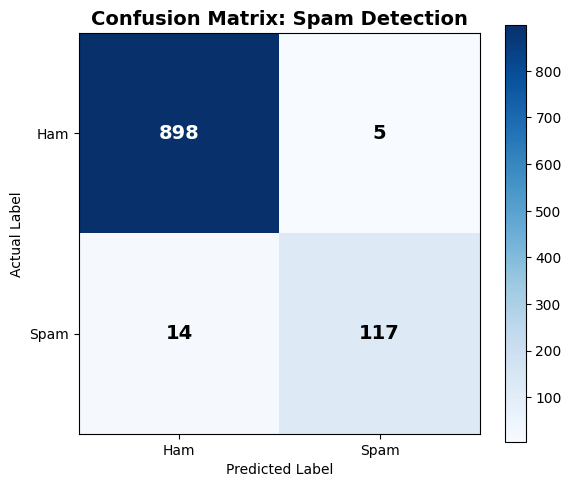


=== INTERPRETATION ===
Out of 903 actual Ham messages, 5 were wrongly flagged as Spam (0.55%).
Out of 131 actual Spam messages, 14 slipped through as Ham (10.69%).

Precision (0.9590) tells us: of all messages the model called 'Spam',
  95.9% actually were spam.
Recall (0.8931) tells us: of all real Spam messages, the model caught 89.3% of them.


In [10]:
# =========================================================
# PHASE 8: MODEL EVALUATION
# =========================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, confusion_matrix, classification_report)

# ---- Step 1: Generate predictions on the TEST set ----
y_pred = model.predict(X_test_vec)

# ---- Step 2: Core metrics ----
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== EVALUATION METRICS (on unseen TEST set) ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# ---- Step 3: Confusion matrix ----
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n=== CONFUSION MATRIX ===")
print(cm)
print(f"\nTrue Negatives (Ham correctly identified):  {tn}")
print(f"False Positives (Ham wrongly flagged Spam): {fp}  <- worse error type")
print(f"False Negatives (Spam that slipped through): {fn}")
print(f"True Positives (Spam correctly identified): {tp}")

# ---- Step 4: Full classification report ----
print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

# ---- Step 5: Confusion matrix heatmap ----
def plot_confusion_matrix(cm: np.ndarray) -> None:
    """
    Plots a heatmap of the confusion matrix using matplotlib.

    Args:
        cm (np.ndarray): 2x2 confusion matrix array
    """
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix: Spam Detection", fontsize=14, fontweight="bold")
    plt.colorbar()

    labels = ["Ham", "Spam"]
    plt.xticks([0, 1], labels)
    plt.yticks([0, 1], labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    # Annotate each cell with its count
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                      ha="center", va="center",
                      color="white" if cm[i, j] > thresh else "black",
                      fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm)

# ---- Step 6: Interpretation ----
print("\n=== INTERPRETATION ===")
print(f"Out of {tn + fp} actual Ham messages, {fp} were wrongly flagged as Spam ({fp/(tn+fp)*100:.2f}%).")
print(f"Out of {fn + tp} actual Spam messages, {fn} slipped through as Ham ({fn/(fn+tp)*100:.2f}%).")
print(f"\nPrecision ({precision:.4f}) tells us: of all messages the model called 'Spam',")
print(f"  {precision*100:.1f}% actually were spam.")
print(f"Recall ({recall:.4f}) tells us: of all real Spam messages, the model caught {recall*100:.1f}% of them.")

# ======================================================
# PHASE 9: REAL-TIME PREDICTION
# ======================================================

In [11]:
# =========================================================
# PHASE 9: REAL-TIME PREDICTION
# =========================================================

def predict_sms(message: str, model: MultinomialNB = model,
                 vectorizer: CountVectorizer = vectorizer) -> dict:
    """
    Predicts whether a given SMS message is Spam or Ham, along with
    the model's confidence (probability) for each class.

    Args:
        message (str): Raw SMS text to classify
        model (MultinomialNB): Trained Naive Bayes model (defaults to our Phase 7 model)
        vectorizer (CountVectorizer): Fitted vectorizer (defaults to our Phase 6 vectorizer)

    Returns:
        dict: Contains the prediction label and both class probabilities
    """
    if not isinstance(message, str) or message.strip() == "":
        raise ValueError("Message must be a non-empty string.")

    # Vectorize the new message using the ALREADY FITTED vectorizer
    # (must be a list, since transform() expects an iterable of documents)
    message_vec = vectorizer.transform([message])

    # Predict class (0 = Ham, 1 = Spam)
    prediction = model.predict(message_vec)[0]

    # Predict probabilities: returns [P(Ham), P(Spam)]
    probabilities = model.predict_proba(message_vec)[0]
    p_ham, p_spam = probabilities[0], probabilities[1]

    label = "Spam" if prediction == 1 else "Ham"

    return {
        "message": message,
        "prediction": label,
        "P(Spam)": round(p_spam, 4),
        "P(Ham)": round(p_ham, 4)
    }


def display_prediction(result: dict) -> None:
    """
    Nicely prints a prediction result dictionary.

    Args:
        result (dict): Output from predict_sms()
    """
    print(f"Message: \"{result['message']}\"")
    print(f"Prediction: {result['prediction']}")
    print(f"  P(Spam) = {result['P(Spam)']}")
    print(f"  P(Ham)  = {result['P(Ham)']}")
    print("-" * 60)


# ---- Test with the example from the project brief ----
test_messages = [
    "Congratulations! You won a free prize. Claim now.",
    "Free entry into our contest.",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account has been suspended, click here to verify.",
    "Can you pick up some milk on your way home?"
]

print("=== REAL-TIME PREDICTIONS ===\n")
for msg in test_messages:
    result = predict_sms(msg)
    display_prediction(result)

# ---- Interactive input (optional - run this cell to type your own message) ----
user_message = input("Enter an SMS message to classify: ")
result = predict_sms(user_message)
print()
display_prediction(result)

=== REAL-TIME PREDICTIONS ===

Message: "Congratulations! You won a free prize. Claim now."
Prediction: Spam
  P(Spam) = 1.0
  P(Ham)  = 0.0
------------------------------------------------------------
Message: "Free entry into our contest."
Prediction: Spam
  P(Spam) = 0.9926
  P(Ham)  = 0.0074
------------------------------------------------------------
Message: "Hey, are we still meeting for lunch tomorrow?"
Prediction: Ham
  P(Spam) = 0.0
  P(Ham)  = 1.0
------------------------------------------------------------
Message: "URGENT! Your account has been suspended, click here to verify."
Prediction: Spam
  P(Spam) = 0.997
  P(Ham)  = 0.003
------------------------------------------------------------
Message: "Can you pick up some milk on your way home?"
Prediction: Ham
  P(Spam) = 0.0
  P(Ham)  = 1.0
------------------------------------------------------------
Enter an SMS message to classify: Hello, we noticed you may be eligible for a special benefit. Please follow the instruction

# ======================================================
# PHASE 10: MODEL SAVING
# ======================================================

In [13]:
# =========================================================
# PHASE 10: MODEL SAVING
# =========================================================
import joblib

# ---- Step 1: Save the trained model ----
model_filename = "sms_spam_detection_model.pkl"
joblib.dump(model, model_filename)
print(f"Model saved as: {model_filename}")

# ---- Step 2: Save the fitted vectorizer ----
vectorizer_filename = "vectorizer.pkl"
joblib.dump(vectorizer, vectorizer_filename)
print(f"Vectorizer saved as: {vectorizer_filename}")

# ---- Step 3: Verify by reloading and testing ----
def load_and_test(model_path: str, vectorizer_path: str, test_message: str) -> dict:
    """
    Loads a saved model and vectorizer from disk, then runs a test
    prediction to confirm they work correctly after reloading.

    Args:
        model_path (str): Path to the saved model .pkl file
        vectorizer_path (str): Path to the saved vectorizer .pkl file
        test_message (str): A message to test the reloaded pipeline with

    Returns:
        dict: Prediction result using the reloaded model/vectorizer
    """
    loaded_model = joblib.load(model_path)
    loaded_vectorizer = joblib.load(vectorizer_path)

    return predict_sms(test_message, model=loaded_model, vectorizer=loaded_vectorizer)

print("\n=== VERIFYING RELOADED MODEL ===")
test_result = load_and_test(model_filename, vectorizer_filename,
                              "Free entry into our contest.")
display_prediction(test_result)

# ---- Step 4: Confirm files exist on disk ----
import os
print("Files saved in current directory:")
for f in [model_filename, vectorizer_filename]:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f} — {size_kb:.2f} KB")

# ---- Step 5: Download files to your local machine (Colab-specific) ----
from google.colab import files
files.download(model_filename)
files.download(vectorizer_filename)

Model saved as: sms_spam_detection_model.pkl
Vectorizer saved as: vectorizer.pkl

=== VERIFYING RELOADED MODEL ===
Message: "Free entry into our contest."
Prediction: Spam
  P(Spam) = 0.9926
  P(Ham)  = 0.0074
------------------------------------------------------------
Files saved in current directory:
  sms_spam_detection_model.pkl — 240.77 KB
  vectorizer.pkl — 90.92 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>